# (11) fit w/ schedulefree + warmup — (T, beta) = (8, 10.0)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:2```

**Motivation**: <br>

schedulefree? does that work?

This time I made sure warmup steps match across the board.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [18]:
from figures.analysis import plot_convergence
from figures.imgs import plot_weights


device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 8
cfg_vae['n_iters'] = 1

# cfg_vae['init_scale'] = 1e-2
# cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 10.0
cfg_tr['optimizer'] = 'schedulefree'

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 8, 'n_iters': 1}

Trainer:
{'batch_size': 200, 'epochs': 300, 'grad_clip': 200, 'kl_beta': 10.0, 'optimizer': 'schedulefree'}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-8_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(10:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_11,15:57)

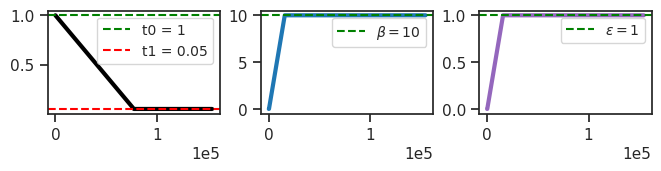

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.optim)

AdamWScheduleFree (
Parameter Group 0
    betas: (0.9, 0.999)
    eps: 1e-08
    foreach: True
    k: 0
    lr: 0.002
    lr_max: -1.0
    r: 0.0
    scheduled_lr: 0.0
    train_mode: False
    warmup_steps: 772
    weight_decay: 0.0003
    weight_lr_power: 2.0
    weight_sum: 0.0
)

In [6]:
cm = 'schedulefree+warmup_wd:3e-4'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 267.247975: 100%|████| 300/300 [2:27:07<00:00, 29.43s/it]


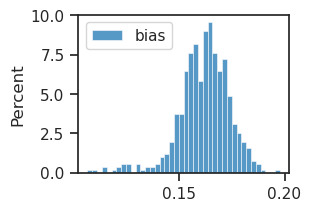

In [9]:
fig, ax = create_figure()

kws = dict(bins=40, stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

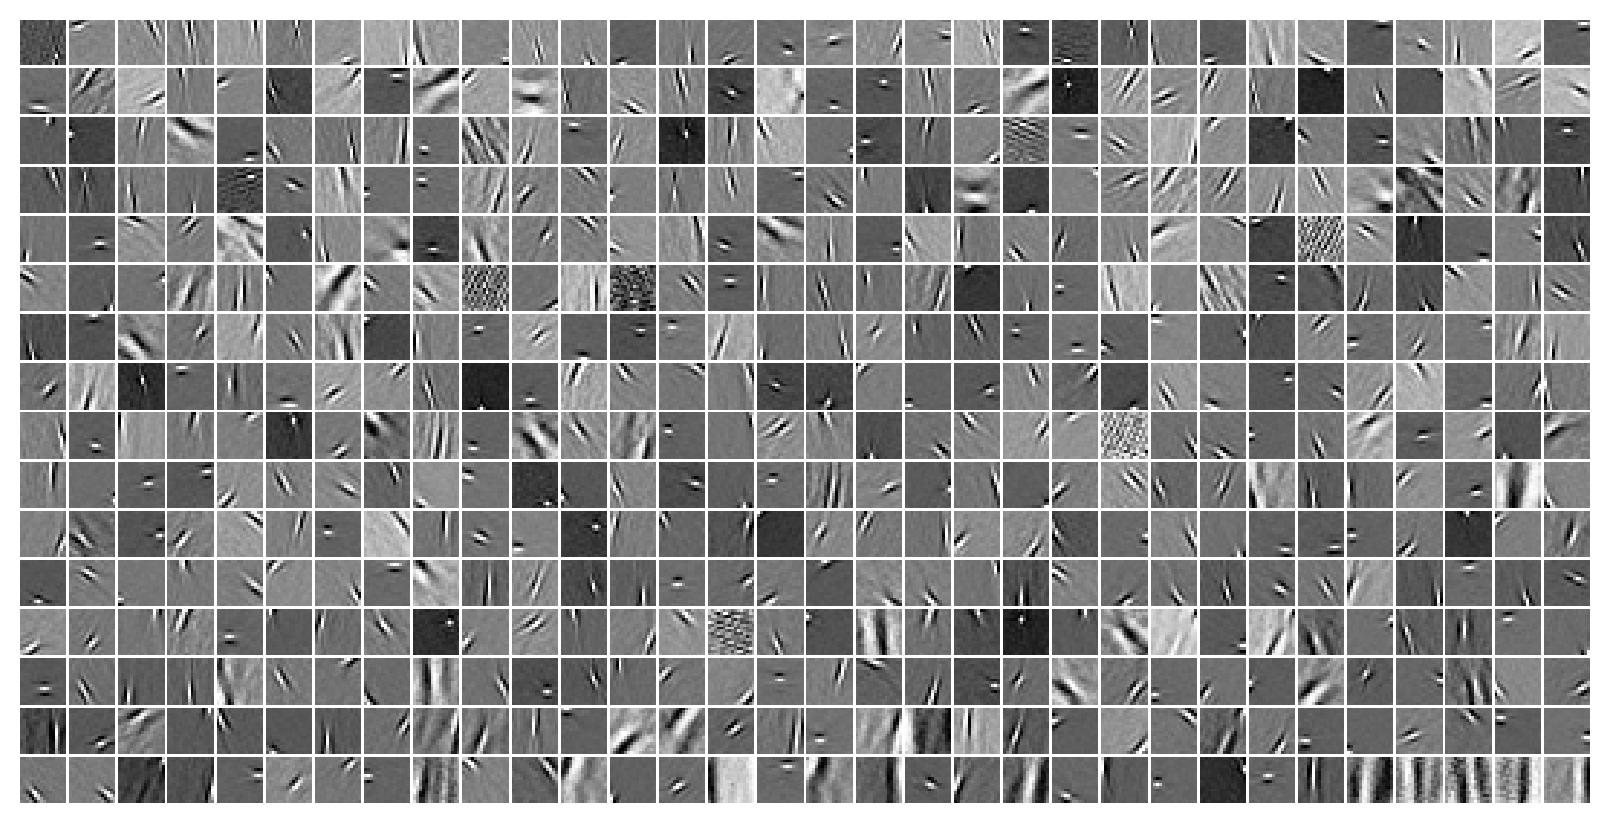

In [10]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

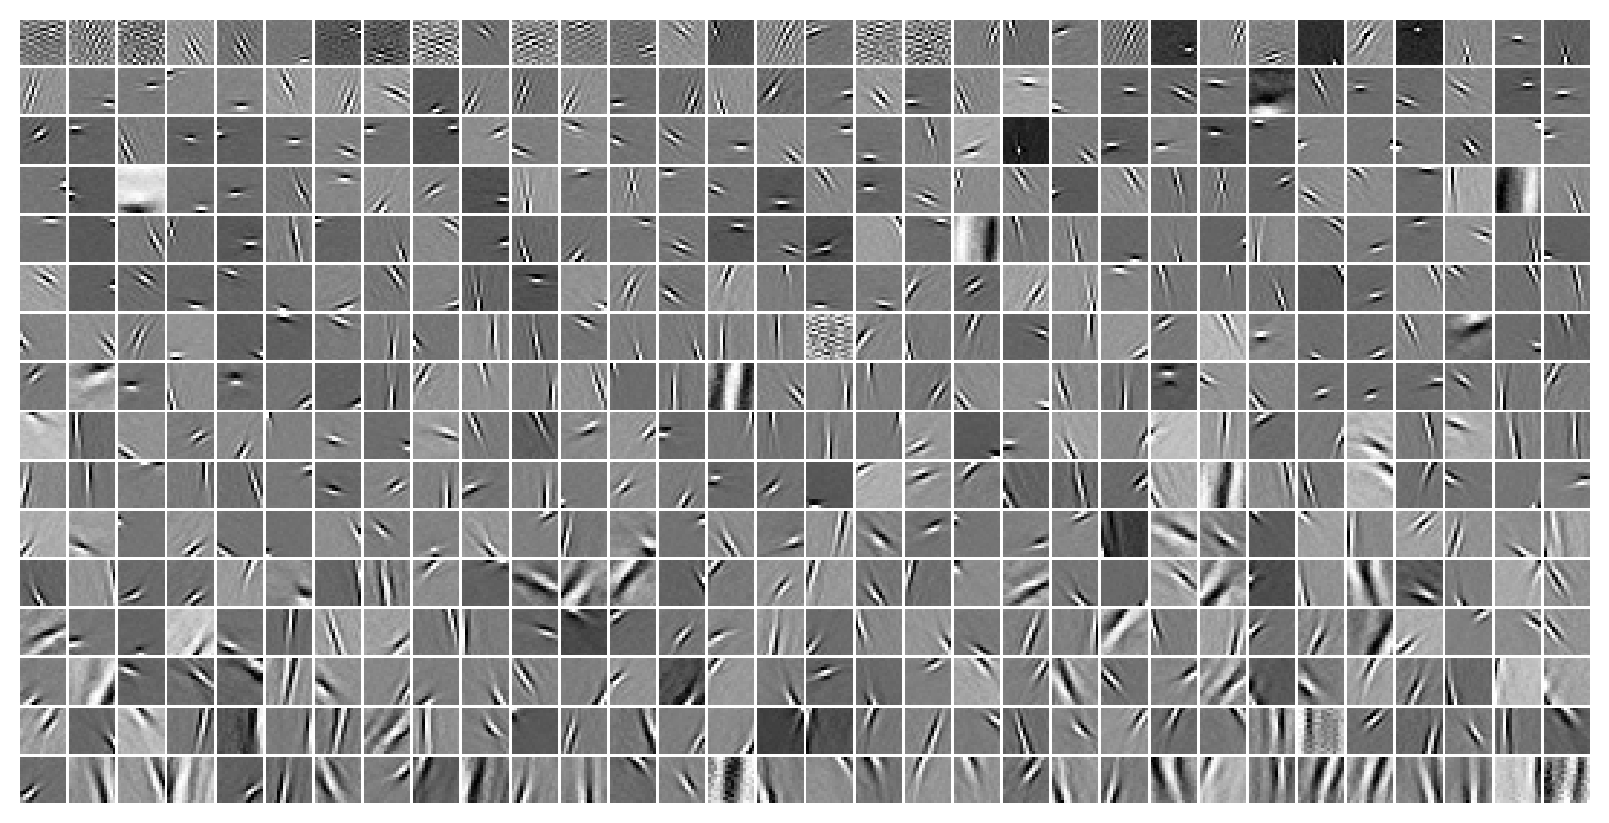

In [9]:
### Was: (T, beta) = (10, 12.0)

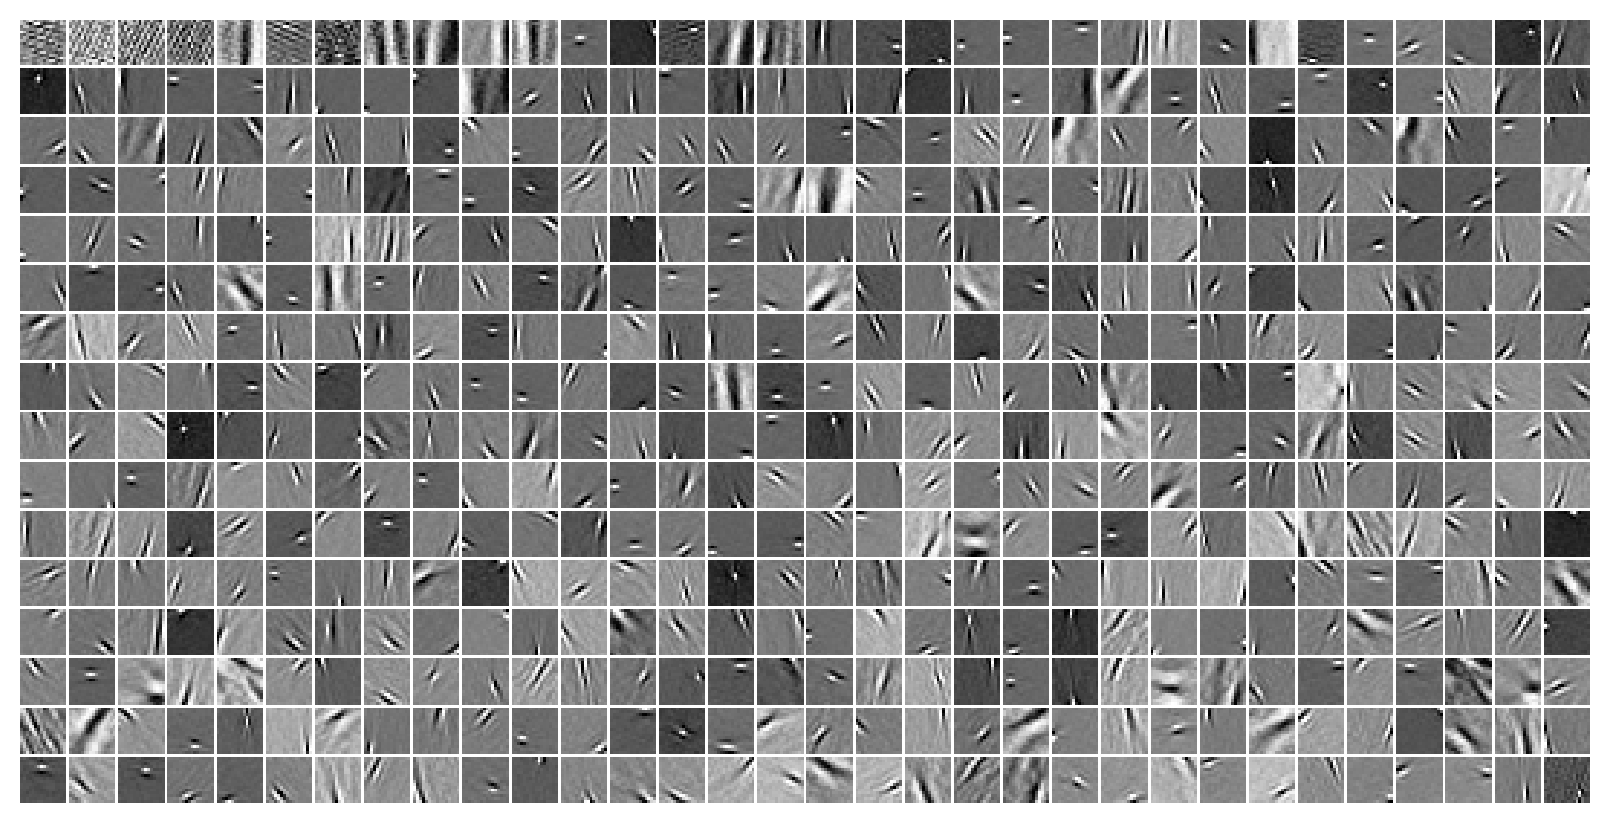

In [11]:
bias = tonp(tr.model.layer.log_bias.exp().squeeze())
tr.model.show(order=np.argsort(bias));

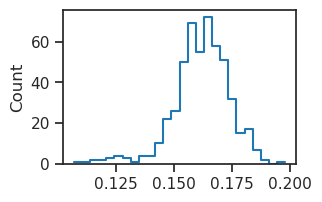

In [12]:
histplot(bias);

100%|███████████████████████████████████| 3/3 [01:54<00:00, 38.33s/it]


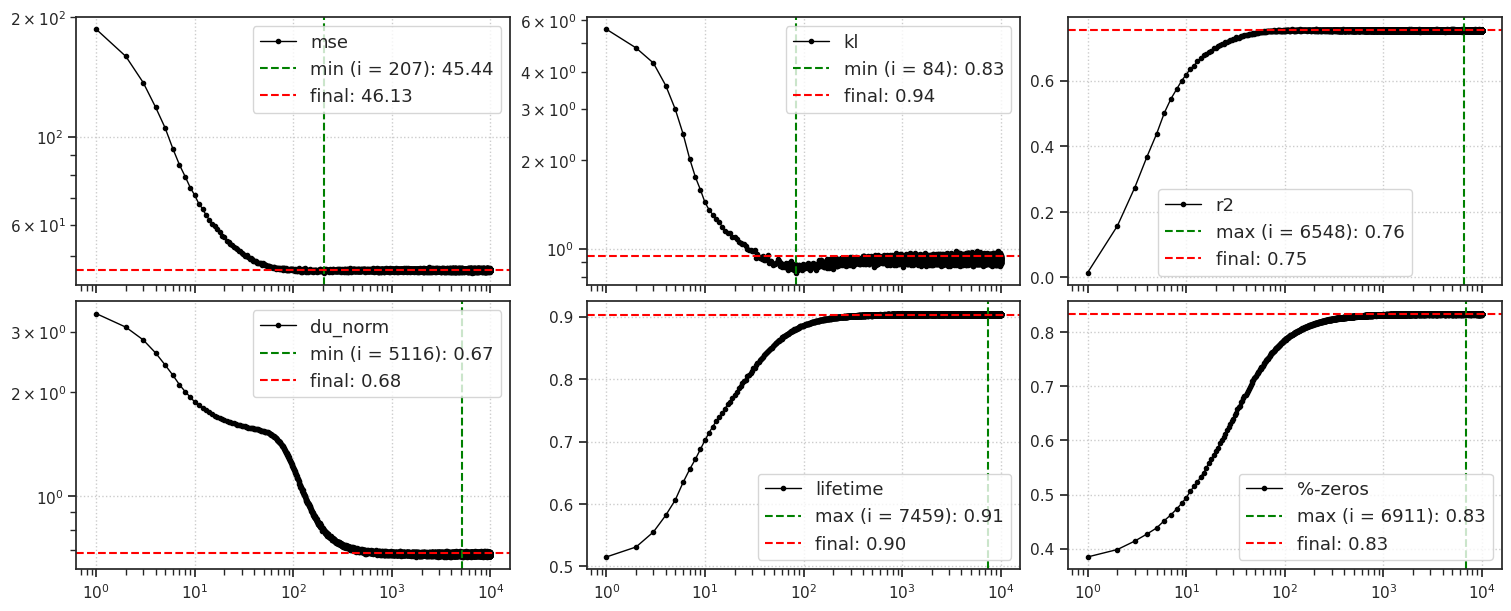

In [13]:
kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=3,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [19]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

CPU times: user 3.02 s, sys: 28.9 ms, total: 3.05 s
Wall time: 3.05 s


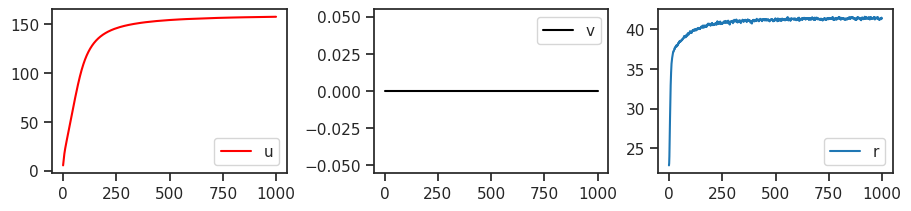

In [20]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

tensor([45.0418, 45.6094, 46.0287, 45.3498, 45.1689], device='cuda:3')

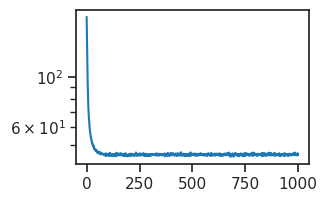

In [15]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

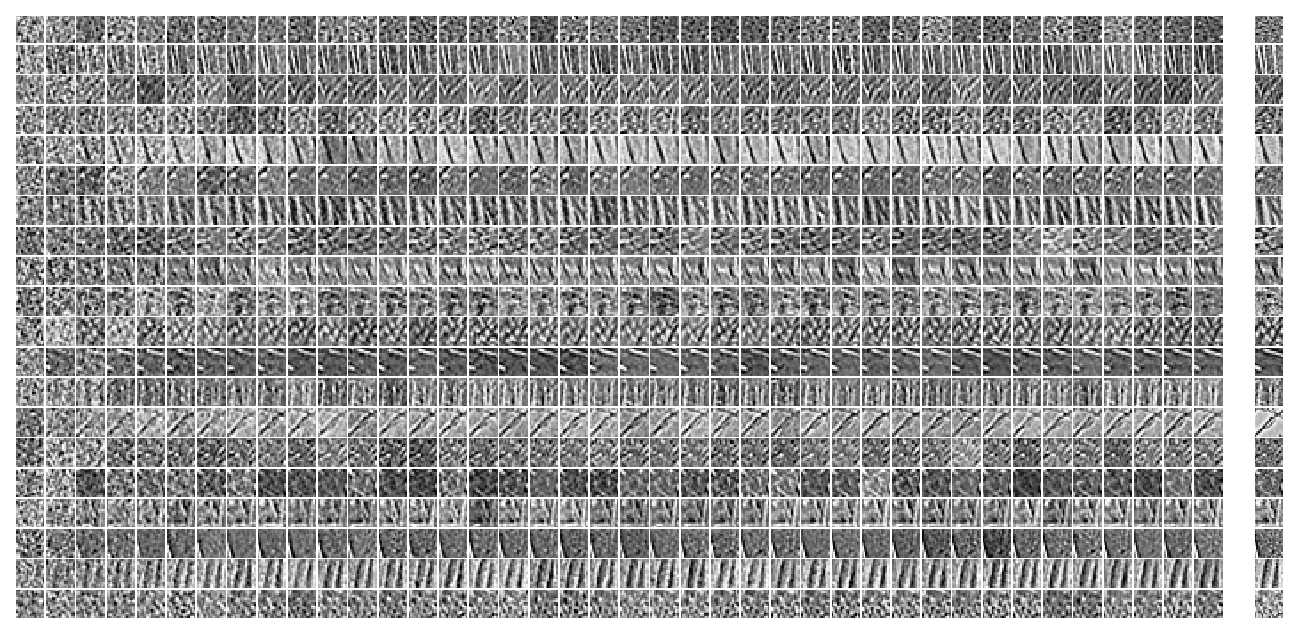

In [16]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

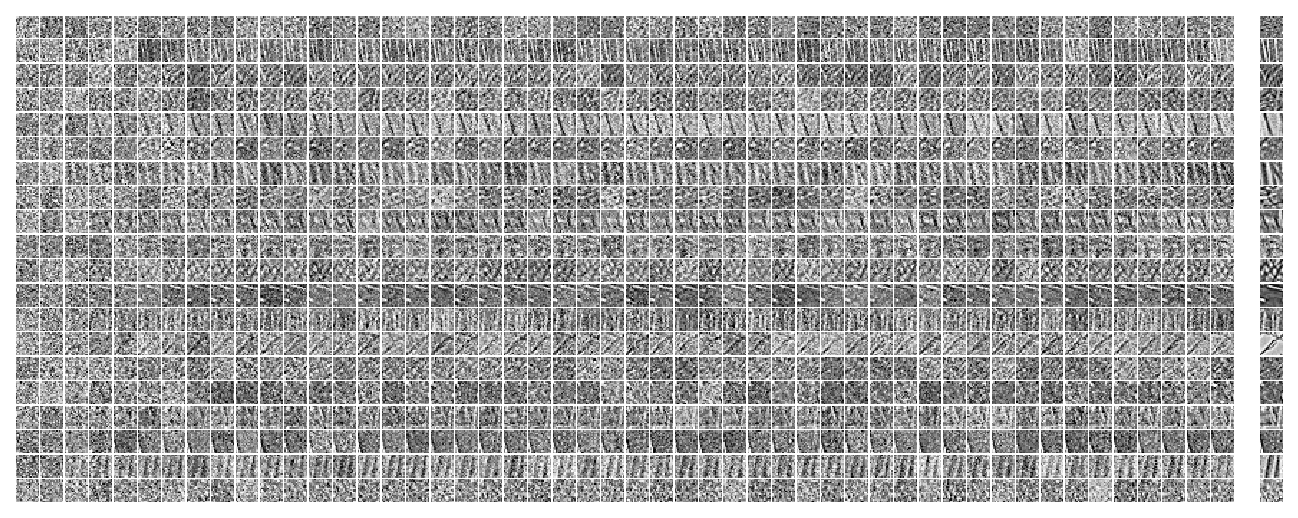

In [17]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)